# L6b Advanced: Residual Diagnostics and Two Bootstrap Methods
The [bootstrap example](../../CHEME-5660-L6b-Example-SIM-Parameter-Uncertainty-Fall-2026.ipynb) drew single index model (SIM) residuals that were uncorrelated from day to day and normally distributed. Do real residuals behave this way, and what happens to the parameter uncertainty when they do not?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Check the residuals for heavy tails:__ Fit the single index model for one firm and compare its residuals with a normal distribution of the same variance. Read the tail index from L3a against a Gaussian reference.
> * __Compare two bootstrap methods:__ Build synthetic datasets by resampling the observed residuals and by drawing Gaussian residuals with the same variance. Compare the resulting standard errors and intervals with the classical ones.
> * __Check for dependence and correct the standard errors:__ Trace the lag-one autocorrelation in the residuals to averaged prices by comparing them with closing prices. Compute autocorrelation-consistent (Newey-West) standard errors and compare them with the classical ones as the number of lags grows.

In this example, we fit one firm against SPY, using the same 2014 to 2024 daily growth rates as the [estimation example](../../CHEME-5660-L6b-Example-SVD-SIM-Estimation-Fall-2026.ipynb).

Let's get started!
___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. This file runs [the L6b setup file](../../Include.jl), which activates the course project, defines local paths, and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
We use each day's volume-weighted average price (VWAP) as the share price. We load the prices with [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep the tickers with a full price history, and build the growth-rate matrix with [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix). We store the prices in `dataset::Dict{String,DataFrame}`, the sorted tickers in `list_of_tickers::Array{String,1}`, and the growth rates (units: inverse years) in `G::Array{Float64,2}`:

In [2]:
dataset, list_of_tickers, G = let

    # Load the prices and keep the tickers with a full history (as many rows as AAPL) -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # ticker => price table
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has a full history
    dataset = Dict(k => v for (k, v) ∈ original_dataset if nrow(v) == maximum_number_trading_days);
    list_of_tickers = keys(dataset) |> collect |> sort; # alphabetical order sets the columns of G

    # Check the prices: log_growth_matrix pairs rows by position, so the dates must agree -
    for ticker ∈ list_of_tickers
        prices = dataset[ticker].volume_weighted_average_price; # daily VWAP (USD/share)
        @assert dataset[ticker].timestamp == dataset["SPY"].timestamp # same trading dates as SPY
        @assert all(isfinite, prices) && all(>(0), prices) # >(0) means x -> x > 0
    end

    # Build the growth-rate matrix G, one row per day and one column per ticker (1/yr) -
    (dataset, list_of_tickers, log_growth_matrix(dataset, list_of_tickers, Δt = 1/252));
end;
N = size(G, 1); # number of daily growth-rate observations
println("N = $(N) daily growth-rate observations for $(length(list_of_tickers)) securities")

N = 2766 daily growth-rate observations for 424 securities


### Constants
Let's set the constants used below. See the comment next to each constant for its definition and units. You can change `my_test_ticker` to any ticker in `list_of_tickers` except `market_ticker`.

In [3]:
# Set the time unit, the market index, the firm we study, and the bootstrap size -
Δt = (1.0/252.0); # time step (1 trading day, in years)
market_ticker = "SPY"; # the SPDR S&P 500 ETF is our proxy for the market index M
my_test_ticker = "AMD"; # the firm we study (try another ticker)
number_of_bootstrap_samples = 2000; # number of synthetic datasets K for each bootstrap
seed = 5660; # random seed for the bootstrap draws, so every run gives the same results

___

## Task 1: Fit the SIM and Check the Residual Distribution
In this task, we fit the SIM for one firm and compare its residuals with the normal distribution that the Gaussian bootstrap draws from. The lecture's model for firm $i$ on trading day $t$ is given by:

$$
g_{i,t} = \alpha_{i} + \beta_{i}\,g_{M,t} + \varepsilon_{i,t}
$$

where $g_{i,t}$ and $g_{M,t}$ are the firm and market growth rates and $\varepsilon_{i,t}$ is the residual, all in inverse years. [The `estimate_sim(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.estimate_sim) fits the model by least squares and returns $\hat{\alpha}_{i}$, $\hat{\beta}_{i}$, the residual standard deviation $s_{g,\varepsilon}$, and the coefficient of determination $R^{2}$. We store the fit in `estimate::MySIMParameterEstimate`:

In [4]:
# Pull out the market and firm columns of G -
g_market = G[:, findfirst(==(market_ticker), list_of_tickers)]; # market growth rates g_M,t (1/yr)
g_firm = G[:, findfirst(==(my_test_ticker), list_of_tickers)]; # firm growth rates g_i,t (1/yr)

# Fit the SIM by least squares -
estimate = estimate_sim(g_market, g_firm, my_test_ticker; δ = 0.0); # δ = 0.0: plain least squares

# Display the estimates -
let
    df = DataFrame(quantity = ["α̂ (1/yr)", "β̂", "s_gε (1/yr)", "R²"],
        value = [estimate.α, estimate.β, estimate.σ_ε, estimate.r²]);
    pretty_table(df, backend = :text, formatters = [fmt__printf("%.4f", [2])],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ------------- ---------
     quantity     value 
       String   Float64 
 ------------- ---------
     α̂ (1/yr)    0.1275
            β̂    1.7392
  s_gε (1/yr)    6.5410
           R²    0.2455
 ------------- ---------


These values match the step-by-step fit in the estimation example.

### Are the residuals normally distributed?
Let's compare the residuals $r_{t}=g_{i,t}-\hat{\alpha}_{i}-\hat{\beta}_{i}\,g_{M,t}$ with a normal distribution of the same variance. The right panel shows, on a log scale, the fraction of residuals whose size exceeds $x$ standard deviations. We store the residuals in `residuals::Array{Float64,1}`:

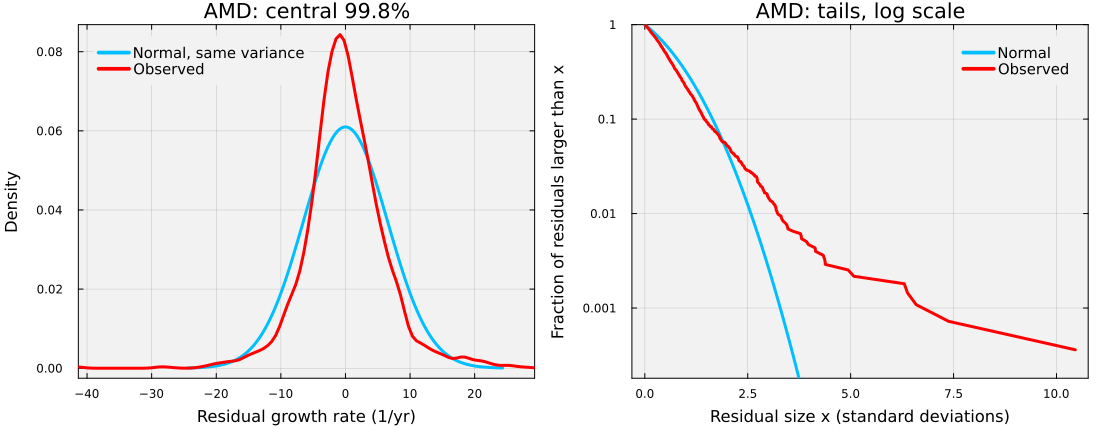

In [5]:
# Compute the residuals r_t = g_i,t - α̂ - β̂ g_M,t (1/yr) -
residuals = g_firm .- (estimate.α .+ estimate.β .* g_market);

let
    # The Gaussian bootstrap's residual model: mean zero, standard deviation s_gε -
    normal_model = Normal(0.0, estimate.σ_ε);
    central_limits = Tuple(quantile(residuals, [0.001, 0.999])); # central 99.8% of the residuals

    # Left panel: the densities near zero, on a linear scale -
    p_density = plot(normal_model, label = "Normal, same variance", c = :deepskyblue1, lw = 3,
        xlims = central_limits, xlabel = "Residual growth rate (1/yr)", ylabel = "Density",
        title = "$(my_test_ticker): central 99.8%", legend = :topleft);
    density!(p_density, residuals, label = "Observed", c = :red, lw = 3); # kernel density estimate

    # Right panel: the fraction of residuals larger than x standard deviations, on a log scale -
    z = sort(abs.(residuals) ./ estimate.σ_ε, rev = true); # residual sizes in standard deviations
    fraction_larger = (1:length(z)) ./ length(z); # m/n of residuals are ≥ the m-th largest
    x = range(0.0, maximum(z), length = 200);
    p_tail = plot(x, 2 .* ccdf.(Normal(), x), label = "Normal", c = :deepskyblue1, lw = 3,
        yscale = :log10, ylims = (0.5/length(z), 1.0),
        yticks = ([0.001, 0.01, 0.1, 1.0], ["0.001", "0.01", "0.1", "1"]),
        xlabel = "Residual size x (standard deviations)",
        ylabel = "Fraction of residuals larger than x",
        title = "$(my_test_ticker): tails, log scale");
    plot!(p_tail, z, fraction_larger, label = "Observed", c = :red, lw = 3);

    # Draw the two panels side by side -
    plot(p_density, p_tail, layout = (1, 2), size = (1100, 430), framestyle = :box,
        bg = "gray95", background_color_outside = "white", fg_legend = :transparent,
        legendfontsize = 10, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
end

The tail index from L3a summarizes the right panel: a smaller index means heavier tails. Let's compare the residuals' index from [the `hill_tail_index(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.hill_tail_index) with the indices of 500 Gaussian samples of the same length:

In [6]:
let
    # Tail index of the residuals, using the L3a reference cutoff k = ⌊√n⌋ (the default) -
    residual_index = hill_tail_index(residuals);

    # Tail index of Gaussian samples with the same length and standard deviation -
    rng = MersenneTwister(seed); # seeded, so every run gives the same draws
    gaussian_index = [hill_tail_index(estimate.σ_ε .* randn(rng, N)) for _ ∈ 1:500];
    q = quantile(gaussian_index, [0.025, 0.5, 0.975]); # middle 95% and median

    # Display the comparison -
    println("Hill tail index, residuals: $(round(residual_index, digits = 2))")
    println("Hill tail index, 500 Gaussian samples: median $(round(q[2], digits = 2)), ",
        "middle 95% from $(round(q[1], digits = 2)) to $(round(q[3], digits = 2))")
end

Hill tail index, residuals: 4.08


Hill tail index, 500 Gaussian samples: median 7.82, middle 95% from 6.33 to 10.08


__What do we see?__ Near zero, the observed density is taller and narrower than the normal curve. Beyond about three standard deviations, the observed fraction stays far above the normal curve. The residuals' tail index falls below the Gaussian range, so large residuals are much more common than the Gaussian bootstrap assumes.

___

## Task 2: Compare Two Bootstraps with the Classical Standard Errors
In this task, we run two bootstraps for the same firm and compare them with the classical standard errors. As in the bootstrap example, each synthetic dataset $k=1,\dots,K$ keeps the market growth rates and adds new residuals to the fitted values:

$$
\mathbf{y}^{(k)}=\hat{\mathbf{X}}\hat{\boldsymbol{\theta}}+\boldsymbol{\varepsilon}^{(k)}
$$

where $\mathbf{y}^{(k)}$ holds the synthetic firm growth rates, $\hat{\mathbf{X}}\hat{\boldsymbol{\theta}}$ the fitted growth rates, and $\boldsymbol{\varepsilon}^{(k)}$ the synthetic residuals. The two bootstraps differ only in where these residuals come from:

* __Empirical-residual bootstrap:__ draw them with replacement from the Task 1 residuals, which keeps their heavy tails.
* __Gaussian bootstrap:__ draw them from a normal distribution with mean zero and standard deviation $s_{g,\varepsilon}$.

Both draw each day's residual independently. [The `bootstrap_sim(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.bootstrap_sim) runs either method and refits $\hat{\alpha}_{i}$, $\hat{\beta}_{i}$, and $s_{g,\varepsilon}$ on each dataset. It returns the bootstrap standard errors, the 95% percentile intervals, and the classical standard errors.

We store the two runs in `residual_bootstrap::NamedTuple` and `parametric_bootstrap::NamedTuple`:

In [7]:
# Run both bootstraps with the same seed and number of datasets K -
# method = :residual resamples the residuals, :parametric draws Gaussian residuals.
residual_bootstrap = bootstrap_sim(g_market, g_firm, my_test_ticker;
    n_bootstrap = number_of_bootstrap_samples, seed = seed, method = :residual);
parametric_bootstrap = bootstrap_sim(g_market, g_firm, my_test_ticker;
    n_bootstrap = number_of_bootstrap_samples, seed = seed, method = :parametric);

let
    # Shorter names for the two runs -
    rb = residual_bootstrap; # empirical-residual bootstrap
    gb = parametric_bootstrap; # Gaussian bootstrap

    # Classical standard errors and 95% interval for β̂, as in the estimation example -
    SE = rb.theoretical_standard_errors; # (alpha = SE(α̂) in 1/yr, beta = SE(β̂))
    t = quantile(TDist(N - 2), 0.975); # two-sided 95% critical value
    β_interval = (estimate.β - t*SE.beta, estimate.β + t*SE.beta); # (low, high)

    # One row per quantity, one column per method -
    # x... splats a (low, high) tuple into two entries of the vector.
    df = DataFrame(
        quantity = ["SE(α̂) (1/yr)", "SE(β̂)", "β̂: 95% low", "β̂: 95% high",
            "s_gε: 95% low (1/yr)", "s_gε: 95% high (1/yr)"],
        residual_bootstrap = [rb.bootstrap_standard_errors.alpha, rb.bootstrap_standard_errors.beta,
            rb.confidence_intervals.beta..., rb.confidence_intervals.sigma_epsilon...],
        gaussian_bootstrap = [gb.bootstrap_standard_errors.alpha, gb.bootstrap_standard_errors.beta,
            gb.confidence_intervals.beta..., gb.confidence_intervals.sigma_epsilon...],
        classical = [SE.alpha, SE.beta, β_interval..., missing, missing]);

    # Display four decimals, with blank cells where there is no classical value -
    pretty_table(df, backend = :text,
        formatters = [(v, i, j) -> ismissing(v) ? "" : v, fmt__printf("%.4f", [2, 3, 4])],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ----------------------- -------------------- -------------------- -----------
               quantity   residual_bootstrap   gaussian_bootstrap   classical 
                 String              Float64              Float64    Float64? 
 ----------------------- -------------------- -------------------- -----------
           SE(α̂) (1/yr)               0.1239               0.1243      0.1245
                  SE(β̂)               0.0567               0.0579      0.0580
             β̂: 95% low               1.6225               1.6286      1.6254
            β̂: 95% high               1.8511               1.8550      1.8529
   s_gε: 95% low (1/yr)               6.1796               6.3710
  s_gε: 95% high (1/yr)               6.9444               6.7146
 ----------------------- -------------------- -------------------- -----------


__What do we see?__

* __Alpha and beta:__ All three methods give nearly the same standard errors and beta intervals. Each refit of alpha and beta differs from the estimate by a weighted sum of the synthetic residuals. Its spread depends only on the residual variance, which both bootstraps nearly match.
* __Residual standard deviation:__ The empirical-residual interval is much wider than the Gaussian one. The spread of $s_{g,\varepsilon}$ depends on how often large residuals occur, and the heavy tails from Task 1 make them more common.

Let's compare the refitted values from the two bootstraps [using the `histogram(...)` function](https://docs.juliaplots.org/stable/api/#Plots.histogram-Tuple):

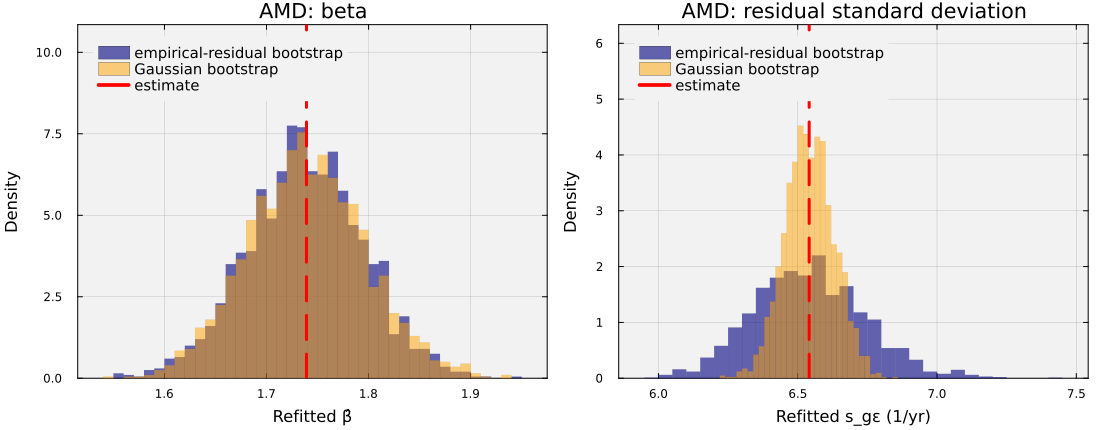

In [8]:
let
    # Left panel: the refitted betas from both bootstraps -
    p1 = histogram(residual_bootstrap.beta_samples, bins = 40, normalize = :pdf, c = :navy,
        alpha = 0.6, lw = 0, label = "empirical-residual bootstrap");
    histogram!(p1, parametric_bootstrap.beta_samples, bins = 40, normalize = :pdf, c = :orange,
        alpha = 0.5, lw = 0, label = "Gaussian bootstrap");
    vline!(p1, [estimate.β], c = :red, lw = 3, ls = :dash, label = "estimate");
    plot!(p1, xlabel = "Refitted β̂", ylabel = "Density", title = "$(my_test_ticker): beta");
    ylims!(p1, (0, 1.4*Plots.ylims(p1)[2])); # headroom above the tallest bar for the legend

    # Right panel: the refitted residual standard deviations -
    p2 = histogram(residual_bootstrap.sigma_epsilon_samples, bins = 40, normalize = :pdf, c = :navy,
        alpha = 0.6, lw = 0, label = "empirical-residual bootstrap");
    histogram!(p2, parametric_bootstrap.sigma_epsilon_samples, bins = 40, normalize = :pdf,
        c = :orange, alpha = 0.5, lw = 0, label = "Gaussian bootstrap");
    vline!(p2, [estimate.σ_ε], c = :red, lw = 3, ls = :dash, label = "estimate");
    plot!(p2, xlabel = "Refitted s_gε (1/yr)", ylabel = "Density",
        title = "$(my_test_ticker): residual standard deviation");
    ylims!(p2, (0, 1.4*Plots.ylims(p2)[2]));

    # Draw the two panels side by side -
    plot(p1, p2, layout = (1, 2), size = (1100, 430), legend = :topleft, legendfontsize = 10,
        bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
end

___

## Task 3: Check the Residuals for Dependence Across Days
In this task, we check whether the residuals are uncorrelated from day to day. We use the sample autocorrelation from L3a for the residuals and for their absolute values, where the absolute values measure volatility clustering.

[The `stylized_facts_report(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.stylized_facts_report) computes both, together with the 95% white-noise band $\pm1.96/\sqrt{N}$. An autocorrelation outside the band is distinguishable from zero at that lag:

In [9]:
let
    # Sample autocorrelations of the residuals and of their absolute values -
    lags = [1, 5, 10, 20, 50]; # lags in trading days
    report = stylized_facts_report(residuals; lags = lags);

    # Display them beside the 95% white-noise band ±1.96/√N -
    band = fill(report.white_noise_95_band, length(lags)); # the same band at every lag
    df = DataFrame(lag = lags, ACF_residual = report.raw_acf,
        ACF_abs_residual = report.absolute_acf, white_noise_band = band);
    pretty_table(df, backend = :text, formatters = [fmt__printf("%.3f", [2, 3, 4])],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ------- -------------- ------------------ ------------------
    lag   ACF_residual   ACF_abs_residual   white_noise_band 
  Int64        Float64            Float64            Float64 
 ------- -------------- ------------------ ------------------
      1          0.169              0.157              0.037
      5         -0.039              0.047              0.037
     10         -0.000              0.032              0.037
     20          0.030              0.041              0.037
     50          0.024              0.013              0.037
 ------- -------------- ------------------ ------------------


__What do we see?__ The lag-one autocorrelation of the residuals is positive and far outside the band. The absolute residuals are also correlated at lag one, so a large residual tends to follow a large one.

### Where does the lag-one dependence come from?
Our share price is the volume-weighted average price (VWAP), an average over the trading day. A price move during day $t$ moves only part of that day's average, and the rest shows up in the next day's average. Consecutive growth rates then share part of the same move ([Working, 1960](https://doi.org/10.2307/1907574)).

If this is the source, nearly every security should show positive lag-one autocorrelation, and it should disappear with closing prices.

Let's test both predictions for every security except SPY. The table reports lag-one autocorrelations across securities, plus the fraction of growth-rate series above the band. The `keycol = :close` keyword of [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) builds the growth rates from closing prices:

In [10]:
let
    # Build the growth rates from closing prices, after the same checks as the VWAP prices -
    for ticker ∈ list_of_tickers
        @assert all(isfinite, dataset[ticker].close) && all(>(0), dataset[ticker].close)
    end
    G_close = log_growth_matrix(dataset, list_of_tickers, Δt = Δt, keycol = :close); # 1/yr

    # Initialize -
    others = findall(!=(market_ticker), list_of_tickers); # every security except the market
    firm = findfirst(==(my_test_ticker), list_of_tickers[others]); # the selected firm among them
    band = 1.96/sqrt(N); # 95% white-noise band
    df = DataFrame(prices = String[], growth_median = Float64[], growth_above_band = Float64[],
        residual_median = Float64[], residual_firm = Float64[]);

    # For each price, the lag-one autocorrelation of every growth-rate series and SIM residual -
    for (prices, M) ∈ [("VWAP", G), ("close", G_close)]
        X̂ = [ones(N) M[:, findfirst(==(market_ticker), list_of_tickers)]]; # design matrix
        growth_acf = [sample_autocorrelation(M[:, i], [1])[1] for i ∈ others];
        residuals_M = M[:, others] .- X̂*(X̂ \ M[:, others]); # refit every SIM, one column each
        residual_acf = [sample_autocorrelation(e, [1])[1] for e ∈ eachcol(residuals_M)];
        push!(df, (prices = prices, growth_median = median(growth_acf),
            growth_above_band = mean(growth_acf .> band), # fraction of securities
            residual_median = median(residual_acf), residual_firm = residual_acf[firm]));
    end

    # Display, with the selected ticker in the last column name -
    rename!(df, :residual_firm => "residual_$(my_test_ticker)");
    pretty_table(df, backend = :text, formatters = [fmt__printf("%.3f", [2, 3, 4, 5])],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------------- ------------------- ----------------- --------------
  prices   growth_median   growth_above_band   residual_median   residual_AMD 
  String         Float64             Float64           Float64        Float64 
 -------- --------------- ------------------- ----------------- --------------
    VWAP           0.104               0.993             0.100          0.169
   close          -0.037               0.031            -0.007         -0.045
 -------- --------------- ------------------- ----------------- --------------


__What do we see?__ With VWAP prices, nearly every security's growth rates are positively correlated at lag one, and so is the typical residual. With closing prices, both medians are near zero or slightly negative. The positive dependence comes from averaging the price over the day, so it affects nearly every SIM we fit to these prices.

### Standard errors that allow for dependence (Newey-West)
The classical covariance of the estimates $\hat{\boldsymbol{\theta}}=(\hat{\alpha}_{i},\hat{\beta}_{i})^{\top}$ is $s^{2}_{g,\varepsilon}(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})^{-1}$, which assumes uncorrelated residuals with a constant variance. The autocorrelation-consistent __Newey-West__ covariance drops both assumptions. It is given by:

$$
\widehat{\mathrm{Cov}}(\hat{\boldsymbol{\theta}})=(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})^{-1}\,\hat{\mathbf{S}}_{L}\,(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})^{-1}
$$

where the middle matrix adds products of the residuals $r_{t}$ and the design-matrix rows $\hat{\mathbf{x}}_{t}^{\top}=(1,\,g_{M,t})$ at lags up to $L$:

$$
\hat{\mathbf{S}}_{L}=\sum_{t=1}^{N}r_{t}^{2}\,\hat{\mathbf{x}}_{t}\hat{\mathbf{x}}_{t}^{\top}+\sum_{\ell=1}^{L}w_{\ell}\sum_{t=\ell+1}^{N}r_{t}\,r_{t-\ell}\left(\hat{\mathbf{x}}_{t}\hat{\mathbf{x}}_{t-\ell}^{\top}+\hat{\mathbf{x}}_{t-\ell}\hat{\mathbf{x}}_{t}^{\top}\right)
$$

The weights $w_{\ell}=1-\ell/(L+1)$ shrink as the lag grows, and a common rule sets $L$ near $N^{1/4}$, about 7 here.

With $L=0$, only the first sum remains, which allows for a changing variance but not for dependence. The standard errors are the square roots of the covariance matrix's diagonal entries. Let's compute them for several values of $L$ and compare with the classical ones:

In [11]:
let
    # Quantities shared by every lag length L -
    X̂ = [ones(N) g_market]; # N × 2 design matrix, row t is x̂ₜᵀ = (1, g_M,t)
    XtX_inv = (transpose(X̂)*X̂) \ I; # (X̂ᵀX̂)⁻¹, computed by a solve
    r = residuals; # residuals rₜ (1/yr)
    SE_classical = sqrt.(estimate.σ_ε^2 .* diag(XtX_inv)); # [SE(α̂) in 1/yr, SE(β̂)]
    df = DataFrame(method = ["classical"], SE_α = [SE_classical[1]], SE_β = [SE_classical[2]],
        ratio_β = [1.0]); # ratio_β = SE(β̂) divided by its classical value

    # Newey-West standard errors for several lag lengths L -
    for L ∈ [0, 5, 10, 20]
        S = zeros(2, 2); # the middle matrix Ŝ_L
        for t ∈ 1:N # first sum: rₜ² x̂ₜ x̂ₜᵀ
            S += r[t]^2 * (X̂[t, :] * transpose(X̂[t, :]));
        end
        for ℓ ∈ 1:L # second sum: lags 1 to L
            w = 1 - ℓ/(L + 1); # the weight shrinks as the lag grows
            for t ∈ (ℓ + 1):N
                P = r[t]*r[t-ℓ] * (X̂[t, :] * transpose(X̂[t-ℓ, :])); # rₜ rₜ₋ℓ x̂ₜ x̂ₜ₋ℓᵀ
                S += w * (P + transpose(P)); # add the term and its transpose
            end
        end
        SE = sqrt.(diag(XtX_inv * S * XtX_inv)); # [SE(α̂) in 1/yr, SE(β̂)]
        push!(df, (method = "Newey-West, L = $(L)", SE_α = SE[1], SE_β = SE[2],
            ratio_β = SE[2]/SE_classical[2]));
    end

    # Display the comparison -
    pretty_table(df, backend = :text,
        formatters = [fmt__printf("%.4f", [2, 3]), fmt__printf("%.3f", [4])],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------------------- --------- --------- ---------
              method      SE_α      SE_β   ratio_β 
              String   Float64   Float64   Float64 
 -------------------- --------- --------- ---------
           classical    0.1245    0.0580     1.000
   Newey-West, L = 0    0.1250    0.0665     1.146
   Newey-West, L = 5    0.1409    0.0828     1.428
  Newey-West, L = 10    0.1395    0.0968     1.668
  Newey-West, L = 20    0.1373    0.1142     1.970
 -------------------- --------- --------- ---------


__What do we see?__ The $L=0$ row adjusts only for the changing variance. Adding lags then raises the standard error of $\hat{\beta}$ well above the classical value, while that of $\hat{\alpha}$ changes much less. Your values will differ if you change `my_test_ticker`.

__So, what happens to the parameter uncertainty when the residuals break these assumptions?__ The heavy tails barely change the uncertainty in alpha and beta, but they widen the interval for the residual standard deviation. The day-to-day dependence matters more for beta: its standard error is larger than the classical formula and both bootstraps report. A block bootstrap, which resamples runs of consecutive days, would keep this dependence.
___

## Summary
In this example, we tested the assumptions behind the classical standard errors and the Gaussian bootstrap on one firm's residuals. We compared two bootstraps with the classical standard errors, traced the day-to-day dependence in the residuals to the averaged prices, and corrected the standard errors for it.

> __Key Takeaways:__
>
> * __Heavy tails matter mainly for the residual scale:__ We found heavier tails in the residuals than in a normal distribution, and compared a bootstrap that resamples them with a Gaussian bootstrap. Both nearly matched the classical standard errors of alpha and beta, but resampling gave a much wider interval for the residual standard deviation.
> * __Averaged prices create day-to-day dependence:__ We found positive lag-one autocorrelation in the residuals and traced it to the volume-weighted average prices. With closing prices, the positive dependence disappeared from nearly every security's growth rates.
> * __Dependence widens the uncertainty in beta:__ We computed Newey-West standard errors, which allow for dependence and a changing variance. The standard error of beta grew with the number of lags and ended well above the classical and bootstrap values.

The L6b lecture takes the point estimates into a portfolio covariance. The [estimation-risk notebook](../estimation-risk/CHEME-5660-L6b-Advanced-EstimationRisk-Fall-2026.ipynb) asks how much uncertain inputs move the portfolio weights.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___